In [15]:
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [16]:
columns = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","num",]

df = pd.read_csv("../data/processed.cleveland.data", names=columns, na_values="?")

display(df)

df['num'] = (df['num']>0).astype(int)

display(df)

df = df.dropna(subset=['num'])

X = df.drop('num',axis=1)
y = df['num']

display(X)
y

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0


0      0
1      1
2      1
3      0
4      0
      ..
298    1
299    1
300    1
301    1
302    0
Name: num, Length: 303, dtype: int64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [18]:
numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent',add_indicator=True)),
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='if_binary'))
])

preprocessor =  ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_columns),
    ('cat', categorical_transformer, categorical_columns)
],
    remainder='passthrough',
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [20]:
model_configs = {
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'poly'],
            'classifier__gamma': ['scale', 'auto']
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [2,3, 5],
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None,2,3, 5, 10],
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42),
        'params': {
            'selector__k': [5, 8, 10, 12, 15, 'all'],
            'classifier__C': [10,11,12,13,14,15,np.inf],
            'classifier__l1_ratio': [0]
        }
    }
}

In [21]:
best_per_model = []
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

for name, config in model_configs.items():
    print(f"Starting tuning for {name}...")

    pipeline.set_params(classifier=config['model'])

    search = GridSearchCV(pipeline, config['params'], cv=cv_strategy, scoring='recall', n_jobs=-1,return_train_score=True)
    search.fit(X_train, y_train)

    best_per_model.append({
        'name': name,
        'estimator': search.best_estimator_,
        'val_score': search.best_score_,
        'cv_results': search.cv_results_
    })

champion = max(best_per_model, key=lambda x: x['val_score'])
print(f"Tournament Winner: {champion['name']} with score: {champion['val_score']:.4f}")
champion['estimator']

Starting tuning for SVM...
Starting tuning for XGBoost...
Starting tuning for RandomForest...
Starting tuning for LogisticRegression...
Tournament Winner: LogisticRegression with score: 0.8104


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [22]:
best_per_model

[{'name': 'SVM',
  'estimator': Pipeline(steps=[('preprocessor',
                   ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                     transformers=[('num',
                                                    Pipeline(steps=[('imputer',
                                                                     KNNImputer()),
                                                                    ('scaler',
                                                                     StandardScaler())]),
                                                    ['age', 'trestbps', 'chol',
                                                     'thalach', 'oldpeak']),
                                                   ('cat',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(add_indicator=True,
                                                                       

In [23]:
for model in best_per_model:
    y_pred = model['estimator'].predict(X_test)

    print("\n" + "=" * 30)
    print("FINAL CLINICAL PERFORMANCE OF", model['name'])
    print("=" * 30)
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix (Row: Actual, Col: Predicted):")
    print(confusion_matrix(y_test, y_pred))
    print("\nval score:")
    print(model['val_score'])


FINAL CLINICAL PERFORMANCE OF SVM
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


Confusion Matrix (Row: Actual, Col: Predicted):
[[29  4]
 [ 2 26]]

val score:
0.7802371541501977

FINAL CLINICAL PERFORMANCE OF XGBoost
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


Confusion Matrix (Row: Actual, Col: Predicted):
[[29  4]
 [ 2 26]]

val score:
0.7920948616600789

FINAL CLINICAL PERFORMANCE OF RandomForest
              precision    rec

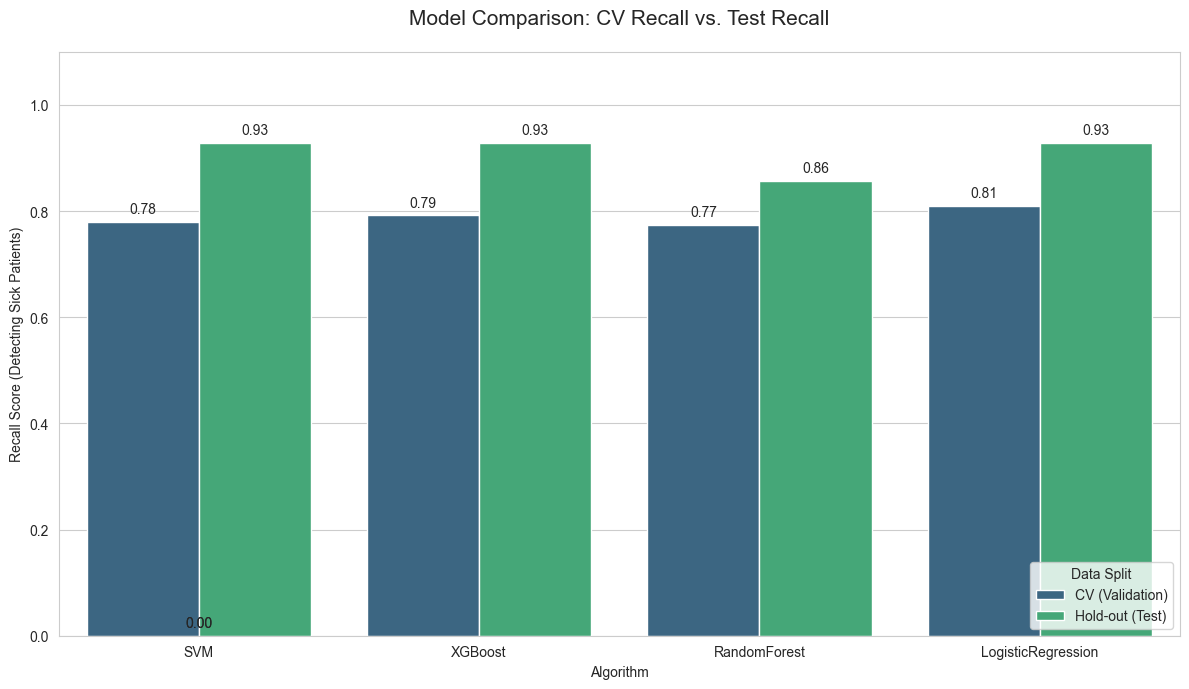

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score

# 1. Prepare the data for plotting
comparison_data = []

for model in best_per_model:
    # Get Test Recall
    y_pred = model['estimator'].predict(X_test)
    test_recall = recall_score(y_test, y_pred)

    comparison_data.append({
        'Model': model['name'],
        'Recall': model['val_score'],
        'Type': 'CV (Validation)'
    })
    comparison_data.append({
        'Model': model['name'],
        'Recall': test_recall,
        'Type': 'Hold-out (Test)'
    })

df_plot = pd.DataFrame(comparison_data)

# 2. Create the visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x='Model', y='Recall', hue='Type', data=df_plot, palette='viridis')

# Aesthetics
plt.title('Model Comparison: CV Recall vs. Test Recall', fontsize=15, pad=20)
plt.ylim(0, 1.1)
plt.ylabel('Recall Score (Detecting Sick Patients)')
plt.xlabel('Algorithm')
plt.legend(title='Data Split', loc='lower right')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [25]:
for model in best_per_model:
    print(model['name'],model['val_score'],model['cv_results'])

SVM 0.7802371541501977 {'mean_fit_time': array([0.04415963, 0.04069362, 0.04613194, 0.04349251, 0.04455781,
       0.04306828, 0.04341259, 0.04096076, 0.04352576, 0.04324568,
       0.04312043, 0.03968267]), 'std_fit_time': array([0.00252326, 0.00223608, 0.00351576, 0.00202364, 0.00467751,
       0.00232876, 0.00280508, 0.00205168, 0.00180103, 0.00204364,
       0.00123008, 0.00466003]), 'mean_score_time': array([0.02694273, 0.02768257, 0.02854166, 0.02895226, 0.02882746,
       0.02677771, 0.02677929, 0.02706704, 0.02720946, 0.02561666,
       0.02618952, 0.02461611]), 'std_score_time': array([0.00125329, 0.00178789, 0.00216274, 0.00301977, 0.00210423,
       0.00108248, 0.00153423, 0.00119186, 0.00189068, 0.00094381,
       0.00130732, 0.00333211]), 'param_classifier__C': masked_array(data=[0.1, 0.1, 0.1, 0.1, 1.0, 1.0, 1.0, 1.0, 10.0, 10.0,
                   10.0, 10.0],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, Fals

In [26]:
import joblib

# Before saving:
champion_pipeline = champion['estimator']
champion_pipeline.val_score_ = champion['val_score'] # Attach a custom attribute

# Save it
joblib.dump(champion_pipeline, '../LogisticRegression.pkl')

['../LogisticRegressionsfsf.pkl']